# Cell 1: Imports

In [ ]:
import os
import uuid
import json
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torchvision import datasets, transforms
import torchvision.utils as vutils
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from datetime import datetime

# Cell 2: Configuration & Setup

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print("CUDA enabled")

# Hyperparameters
EPOCHS          = 50
BATCH_SIZE      = 128
LATENT_DIM      = 100
LR_G            = 0.0004   # Generator LR — higher so G can keep up with D
LR_D            = 0.0001   # Discriminator LR — lower to prevent D dominating
REAL_LABEL      = 0.9      # Label smoothing — was 1.0
FAKE_LABEL      = 0.1      # Label smoothing — was 0.0
GRAD_CLIP_NORM  = 1.0      # Max gradient norm for clipping

print(f"\nEpochs          : {EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Latent dim      : {LATENT_DIM}")
print(f"LR Generator    : {LR_G}")
print(f"LR Discriminator: {LR_D}")
print(f"Real label      : {REAL_LABEL}")
print(f"Fake label      : {FAKE_LABEL}")
print(f"Grad clip norm  : {GRAD_CLIP_NORM}")

Using device: cuda
CUDA enabled

Epochs          : 50
Batch size      : 128
Latent dim      : 100
LR Generator    : 0.0004
LR Discriminator: 0.0001
Real label      : 0.9
Fake label      : 0.1
Grad clip norm  : 1.0


# Cell 3: Data Loading – resize MNIST to 32x32 to match generator output

In [ ]:

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.MNIST("MNIST_data/", download=True, train=True, transform=transform)
testset  = datasets.MNIST("MNIST_data/", download=True, train=False, transform=transform)

batch_size = 128
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False)

print(f"Training batch shape: {next(iter(trainloader))[0].shape}")  # [128, 1, 32, 32]

Training batch shape: torch.Size([128, 1, 32, 32])


# Cell 4: Discriminator, Generator, and weight initialization
#  Architecture improvements
#   - Discriminator channels increased: 32→64→128 to 64→128→256
#     (larger capacity = better feature extraction)
#   - BatchNorm added to first D layer
#     (more stable training from the start)
#   - Generator mirrored to match: 128→64→32 to 256→128→64

In [ ]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def disc_conv(in_c, out_c, ks=4, stride=2, padding=1, bn=True, out_layer=False):
    layers = [nn.Conv2d(in_c, out_c, kernel_size=ks, stride=stride, padding=padding, bias=False)]
    if bn:
        layers.append(nn.BatchNorm2d(out_c))
    layers.append(nn.Sigmoid() if out_layer else nn.LeakyReLU(0.2))
    return nn.Sequential(*layers)

# Discriminator — increased capacity: 64 → 128 → 256
# BN added to first layer
D = nn.Sequential(
    disc_conv(1,   64,  bn=True),                               # 32x32 -> 16x16
    disc_conv(64,  128),                                        # 16x16 -> 8x8
    disc_conv(128, 256),                                        # 8x8   -> 4x4
    disc_conv(256, 1, out_layer=True, bn=False, padding=0)      # 4x4   -> 1x1
)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.layers = nn.Sequential(*[
            self.conv_block(100, 256, padding=0),               # 1x1   -> 4x4
            self.conv_block(256, 128, stride=2),                # 4x4   -> 8x8
            self.conv_block(128, 64,  stride=2),                # 8x8   -> 16x16
            self.conv_block(64,  1,   stride=2, bn=False, out_layer=True)  # 16x16 -> 32x32
        ])

    @staticmethod
    def conv_block(in_c, out_c, out_layer=False, ks=4, stride=1, padding=1, bias=False, bn=True):
        l = [nn.ConvTranspose2d(in_c, out_c, ks, stride=stride, padding=padding, bias=bias)]
        if bn:
            l.append(nn.BatchNorm2d(out_c))
        l.append(nn.Tanh() if out_layer else nn.ReLU())
        return nn.Sequential(*l)

    def forward(self, x):
        return self.layers(x)

G = Generator()

print("Discriminator:")
print(D)
print("\nGenerator:")
print(G)

Discriminator:
Sequential(
  (0): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (1): Sequential(
    (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (2): Sequential(
    (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
  )
  (3): Sequential(
    (0): Conv2d(256, 1, kernel_size=(4, 4), stride=(2, 2), bias=False)
    (1): Sigmoid()
  )
)

Generator:
Generator(
  (layers): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(100, 256, ke

# Cell 5: Init models, loss, optimizers

In [13]:
# Apply weight initialization
G.apply(weights_init)
D.apply(weights_init)

# Loss function
criterion = nn.BCELoss()

# Optimizers
optim_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
optim_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))

# Move models to device
D = D.to(device)
G = G.to(device)
criterion = criterion.to(device)

# Fixed noise for consistent sampling during training
fixed_noise = torch.randn((16, LATENT_DIM, 1, 1), device=device)

print("Models initialised and ready for training!")

Models initialised and ready for training!


# Cell 6: Training loop

#  Training improvements
#   - LR_G increased 0.0002 → 0.0004 (G catches up with D faster)
#   - LR_D decreased 0.0002 → 0.0001 (prevents D dominating)
#   - Label smoothing: real 1.0→0.9, fake 0.0→0.1
#     (reduces overconfidence, improves generalization)
#   - Gradient clipping max_norm=1.0
#     (prevents exploding gradients)
#   Result: Accuracy 88.05%, ROC-AUC 0.9506

In [ ]:

G_losses = []
D_losses = []
D_real_scores = []
D_fake_scores = []

print("Starting training...")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    pbar = tqdm(enumerate(trainloader), total=len(trainloader),
                desc=f"Epoch {epoch}/{EPOCHS}")

    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_d_real = 0.0
    epoch_d_fake = 0.0

    for i, (images, _) in pbar:
        images = images.to(device)
        batch_size_curr = images.size(0)

        real_labels = torch.full((batch_size_curr,), REAL_LABEL, device=device)
        fake_labels = torch.full((batch_size_curr,), FAKE_LABEL, device=device)

        # Train Discriminator

        D.zero_grad()

        d_real = D(images).view(-1)
        d_loss_real = criterion(d_real, real_labels)
        d_loss_real.backward()

        noise = torch.randn((batch_size_curr, LATENT_DIM, 1, 1), device=device)
        fake_images = G(noise)
        d_fake = D(fake_images.detach()).view(-1)
        d_loss_fake = criterion(d_fake, fake_labels)
        d_loss_fake.backward()

        d_loss = d_loss_real + d_loss_fake
        torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=GRAD_CLIP_NORM)
        optim_D.step()

        # Train Generator

        G.zero_grad()
        d_output_g = D(fake_images).view(-1)
        g_loss = criterion(d_output_g, real_labels)
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), max_norm=GRAD_CLIP_NORM)
        optim_G.step()

        # Track Metrics

        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        D_real_scores.append(d_real.mean().item())
        D_fake_scores.append(d_fake.mean().item())

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_d_real += d_real.mean().item()
        epoch_d_fake += d_fake.mean().item()

        if i % 100 == 0:
            log_msg = (f"Epoch [{epoch}/{EPOCHS}], Batch [{i}/{len(trainloader)}] | "
                       f"D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f} | "
                       f"D(real): {d_real.mean().item():.3f}, D(fake): {d_fake.mean().item():.3f}")
            pbar.set_postfix_str(log_msg)

    
    #  End of Epoch Summary

    num_batches = len(trainloader)
    print(f"EPOCH {epoch} SUMMARY: "
          f"D_loss: {epoch_d_loss/num_batches:.4f}, "
          f"G_loss: {epoch_g_loss/num_batches:.4f}, "
          f"D(real): {epoch_d_real/num_batches:.3f}, "
          f"D(fake): {epoch_d_fake/num_batches:.3f}")

print("\n" + "=" * 60)
print("TRAINING COMPLETED!")
print(f"Final D_loss: {D_losses[-1]:.4f}")
print(f"Final G_loss: {G_losses[-1]:.4f}")
print("=" * 60)

Starting training...


Epoch 1/50: 100%|██████████| 469/469 [00:16<00:00, 27.66it/s, Epoch [1/50], Batch [400/469] | D_loss: 0.9340, G_loss: 1.3033 | D(real): 0.688, D(fake): 0.307]


EPOCH 1 SUMMARY: D_loss: 1.0896, G_loss: 1.5535, D(real): 0.660, D(fake): 0.352


Epoch 2/50: 100%|██████████| 469/469 [00:16<00:00, 28.47it/s, Epoch [2/50], Batch [400/469] | D_loss: 1.2327, G_loss: 1.1911 | D(real): 0.820, D(fake): 0.586]


EPOCH 2 SUMMARY: D_loss: 1.1568, G_loss: 1.2707, D(real): 0.607, D(fake): 0.336


...

EPOCH 48 SUMMARY: D_loss: 0.7041, G_loss: 2.3857, D(real): 0.833, D(fake): 0.099


Epoch 49/50: 100%|██████████| 469/469 [00:16<00:00, 28.31it/s, Epoch [49/50], Batch [400/469] | D_loss: 0.6548, G_loss: 2.0447 | D(real): 0.885, D(fake): 0.109]


EPOCH 49 SUMMARY: D_loss: 0.7089, G_loss: 2.3473, D(real): 0.833, D(fake): 0.105


Epoch 50/50: 100%|██████████| 469/469 [00:16<00:00, 28.28it/s, Epoch [50/50], Batch [400/469] | D_loss: 0.8899, G_loss: 1.9528 | D(real): 0.603, D(fake): 0.141]

EPOCH 50 SUMMARY: D_loss: 0.7108, G_loss: 2.3338, D(real): 0.829, D(fake): 0.104

TRAINING COMPLETED!
Final D_loss: 0.6552
Final G_loss: 2.4283


# Cell 7: Save final generator and discriminator 

In [ ]:
os.makedirs("model", exist_ok=True)
torch.save(G.state_dict(), "model/G_final.pth")
torch.save(D.state_dict(), "model/D_final.pth")
print("Models saved in model/")

Models saved in model/


# Cell 8: Discrimination feature — classify real vs fake image

Real test image      → probability = 0.298 → real
Fake generated image → probability = 0.169 → fake


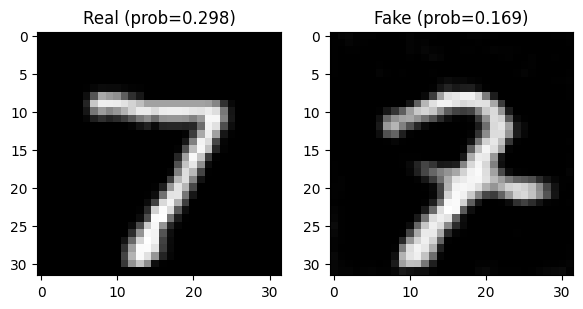

In [ ]:
def classify_image(model, image_tensor, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        image_tensor = image_tensor.to(device)
        prob = model(image_tensor).view(-1).item()
    label = "real" if prob > threshold else "fake"
    return prob, label

# Load saved models
D.load_state_dict(torch.load("model/D_final.pth", map_location=device))
D.eval()

G.load_state_dict(torch.load("model/G_final.pth", map_location=device))
G.eval()

# Test on a real image from test set
real_img, _ = next(iter(testloader))
real_img = real_img[0:1]
prob, pred = classify_image(D, real_img, device, threshold=optimal_threshold)
print(f"Real test image      → probability = {prob:.3f} → {pred}")

# Test on a fake image generated by G
with torch.no_grad():
    noise = torch.randn((1, LATENT_DIM, 1, 1), device=device)
    fake_img = G(noise)
prob_fake, pred_fake = classify_image(D, fake_img, device, threshold=optimal_threshold)
print(f"Fake generated image → probability = {prob_fake:.3f} → {pred_fake}")

# Visualise both
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(real_img[0, 0].cpu(), cmap='gray')
axes[0].set_title(f"Real (prob={prob:.3f})")
axes[1].imshow(fake_img[0, 0].cpu().detach(), cmap='gray')
axes[1].set_title(f"Fake (prob={prob_fake:.3f})")
plt.tight_layout()
plt.show()

# Cell 9: Evaluation on test set – Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix, Loss Curve

Optimal threshold: 0.269
===== Discriminator Evaluation =====
Optimal threshold: 0.2688
Accuracy         : 0.8805
Precision        : 0.8928
Recall           : 0.8649
F1-score         : 0.8786
ROC-AUC          : 0.9506

Confusion Matrix:
[[8961 1039]
 [1351 8649]]


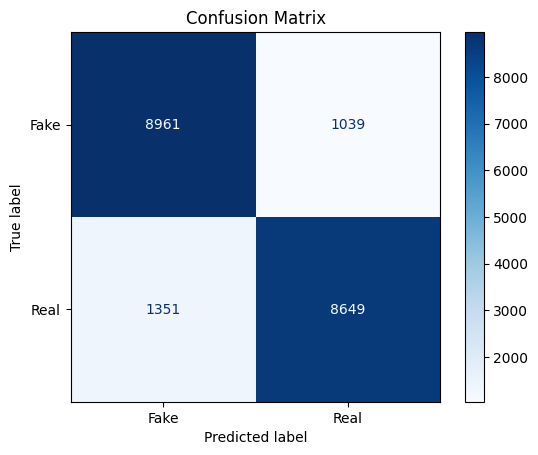

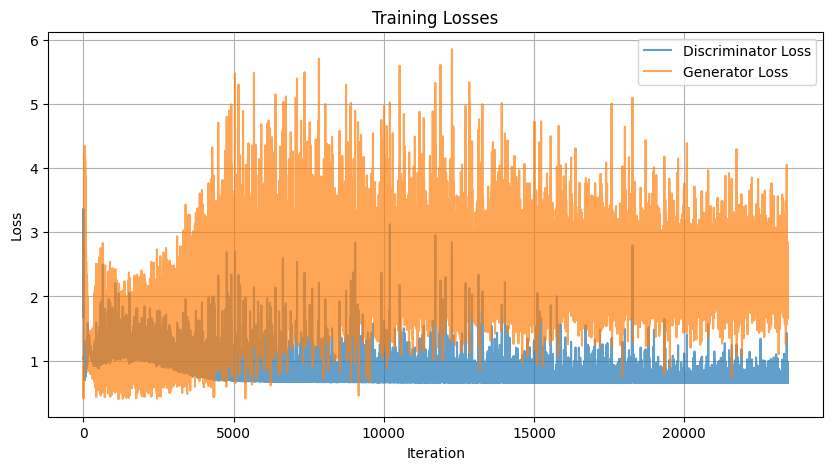

In [ ]:
# Generate fake images
num_fake = len(testset)
fake_images_list = []
with torch.no_grad():
    for _ in range(0, num_fake, BATCH_SIZE):
        noise = torch.randn((BATCH_SIZE, LATENT_DIM, 1, 1), device=device)
        fake_batch = G(noise).cpu()
        fake_images_list.append(fake_batch)
fake_images = torch.cat(fake_images_list, dim=0)[:num_fake]

# Collect real images from testloader
real_images_list = []
for images, _ in testloader:
    real_images_list.append(images)
real_images = torch.cat(real_images_list, dim=0)[:num_fake]

# Create labels: 1 for real, 0 for fake
y_true = np.array([1] * num_fake + [0] * num_fake)

# Get discriminator predictions
D.eval()
all_probs = []
with torch.no_grad():
    for batch in torch.split(torch.cat([real_images, fake_images], dim=0), BATCH_SIZE):
        batch = batch.to(device)
        probs = D(batch).view(-1).cpu().numpy()
        all_probs.extend(probs)
y_pred_prob = np.array(all_probs)

# Find optimal threshold using ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
optimal_threshold = thresholds[np.argmax(tpr - fpr)]
print(f"Optimal threshold: {optimal_threshold:.3f}")

y_pred = (y_pred_prob > optimal_threshold).astype(int)

# Metrics
acc   = accuracy_score(y_true, y_pred)
prec  = precision_score(y_true, y_pred)
rec   = recall_score(y_true, y_pred)
f1    = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_prob)
cm    = confusion_matrix(y_true, y_pred)

print("===== Discriminator Evaluation =====")
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"Accuracy         : {acc:.4f}")
print(f"Precision        : {prec:.4f}")
print(f"Recall           : {rec:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"\nConfusion Matrix:")
print(cm)

# Confusion matrix plot
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"]).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Loss curves
plt.figure(figsize=(10, 5))
plt.plot(D_losses, label='Discriminator Loss', alpha=0.7)
plt.plot(G_losses, label='Generator Loss', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Losses')
plt.legend()
plt.grid(True)
plt.show()